We consider 2D Incompressible MHD, with diffusion

Consider, 
\begin{align}
d_t \omega_t + J(\psi ,\omega) dt + \sum_{p=1}^{P}J(\psi ,\omega) \circ dW^{p}  - J(A,j)dt - \sum_{q=1}^{Q}J(A,j_q) \circ dZ^q &= \nu_1 \Delta \omega + \nu_2 \Delta \omega,\\
d_t A_t + J(\psi,A)dt + \sum_{q=1}^{Q}J(\psi_{q},A)\circ dZ^{q}  &= \mu_1 \Delta \omega + \mu_2 \Delta \omega.
\end{align}
Taking the fourier transform gives
\begin{align}
d_t \widehat{\omega} + \widehat{J}(\psi^*,\omega)  - \widehat{J}(A^*,j) &= \mu_1(k_x^2 + k_y^2)\widehat{\omega} + \mu_2(k_x^4 + k_y^4)\widehat{\omega} \\
d_t \widehat{j} + \widehat{J}(\psi^*,j) &=\nu_1(k_x^2 + k_y^2)\widehat{j} + \nu_2(k_x^4 + k_y^4)\widehat{j}
\end{align}

One can solve with SETDTK4. 

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "true"
import sys
sys.path.append('..')
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from ipywidgets import interact
from ml_collections import ConfigDict
from models.S_MHD import *
from jax import config
jax.config.update("jax_enable_x64", True)
import numpy as np
from matplotlib.animation import FuncAnimation
from ml_collections import ConfigDict  # For parameters dictionary
import numpy as np
from matplotlib.animation import FuncAnimation

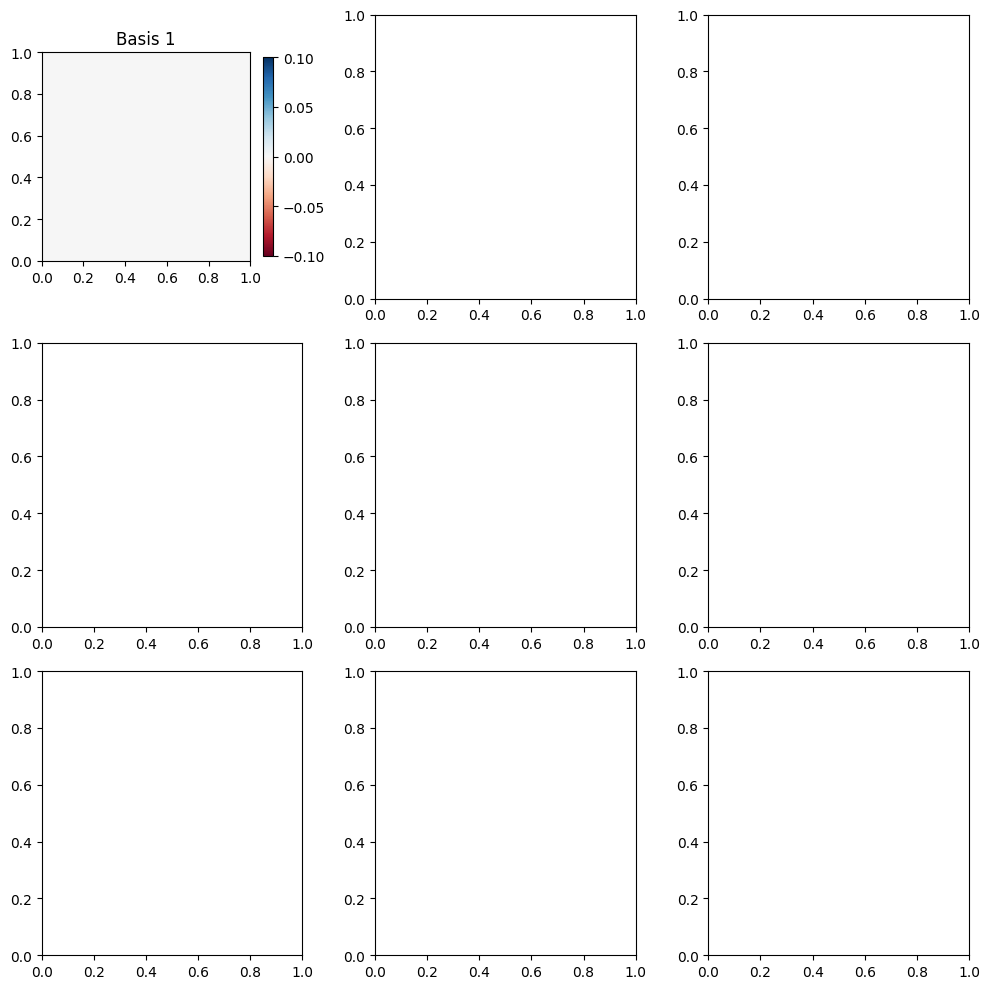

In [2]:
params = ConfigDict(MHD_params)
signal_model = MHD_SETD_KT_CM_JAX(params) 
xmin, xmax, nx, S_1,S_2,S_3, E, tmax, dt, mu = signal_model.params["xmin"],signal_model.params["xmax"],signal_model.params["nt"],signal_model.params["S_1"],signal_model.params["S_2"],signal_model.params["S_3"],signal_model.params["E"],signal_model.params["tmax"],signal_model.params["dt"],signal_model.params["mu"]
L,Nt,dx = signal_model.params["L"], signal_model.params["Nt"], signal_model.params["dx"]
x = signal_model.x
xx, yy = signal_model.xx, signal_model.yy
kx, ky = signal_model.kx, signal_model.ky
ksq = signal_model.ksq
Lhat = signal_model.Lhat
E_1,E_2,Q,f1,f2,f3 = signal_model.E_1, signal_model.E_2, signal_model.Q, signal_model.f1, signal_model.f2, signal_model.f3
basis_1 = signal_model.basis_1
basis_2 = signal_model.basis_2
basis_3 = signal_model.basis_3
q_ic = initial_condition(xx,yy,E,name=params['initial_condition'])*0 
A_ic = initial_condition(xx,yy,E,name=params['initial_condition'])*0.000001# this gives vortex sheets and blow up as expected.
# Plot the basis functions
num_to_plot = min(9, basis_1.shape[0])  # Plot at most 9 basis functions
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i in range(num_to_plot):
    ax = axs.flat[i]
    #print('basis[i]',basis[i].shape,basis[i].dtype,basis[i])
    im = ax.imshow(basis_1[i,:,:], extent=[xmin, xmax, xmin, xmax], origin="lower", cmap="RdBu", aspect='equal')
    ax.set_title(f"Basis {i+1}")
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

dWs = np.random.randn(Nt, basis_1.shape[0])* jnp.sqrt(dt)/dt 
output = signal_model.run_2(initial_state=(q_ic, A_ic), n_steps=signal_model.params['Nt'], noise=None, key=jax.random.PRNGKey(0), save_every=16)
(A0, B0), (A_hist, B_hist) = output


T = 500


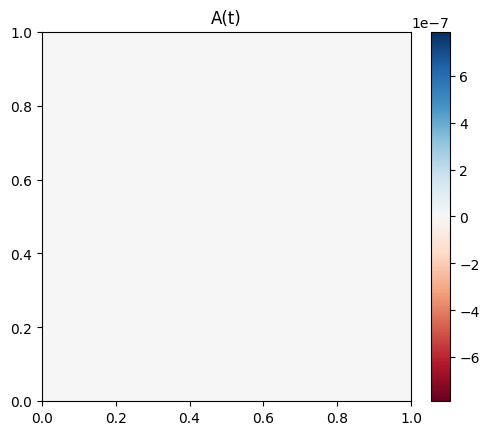

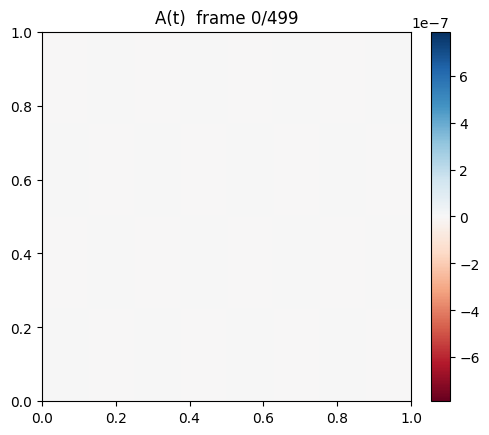

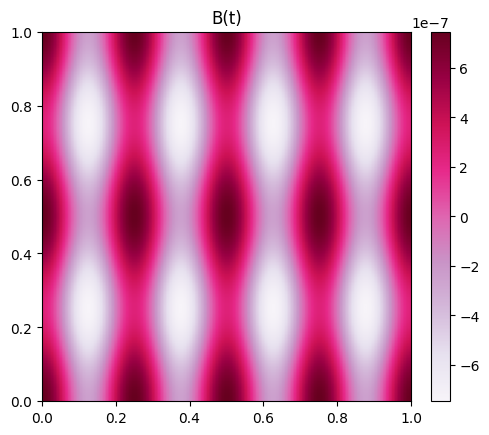

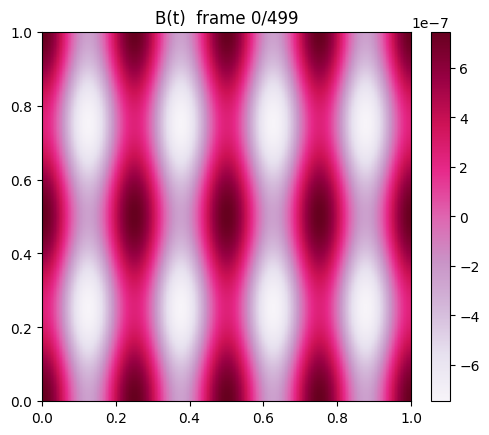

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Convert JAX -> NumPy, drop the singleton channel axis (1 ensemble member)
framesA = np.asarray(A_hist)[:, 0, :, :]   # (T, 128, 128)
framesB = np.asarray(B_hist)[:, 0, :, :]   # (T, 128, 128)
T = framesA.shape[0]
print("T =", T)

# Fix color scale across time
vminA, vmaxA = framesA.min(), framesA.max()
vminB, vmaxB = framesB.min(), framesB.max()

# --- Animate A ---
fig, ax = plt.subplots()
im = ax.imshow(
    framesA[0],
    extent=[xmin, xmax, xmin, xmax],
    origin="lower",
    cmap="RdBu",
    aspect="equal",
    vmin=vminA,
    vmax=vmaxA,
)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("A(t)")

display(fig)
for i in range(T):
    im.set_data(framesA[i])
    ax.set_title(f"A(t)  frame {i}/{T-1}")
    fig.canvas.draw_idle()
    plt.pause(0.01)        # controls speed
plt.close(fig)

# --- Animate B ---
fig, ax = plt.subplots()
im = ax.imshow(
    framesB[0],
    extent=[xmin, xmax, xmin, xmax],
    origin="lower",
    cmap="PuRd",
    aspect="equal",
    vmin=vminB,
    vmax=vmaxB,
)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("B(t)")

display(fig)
for i in range(T):
    im.set_data(framesB[i])
    ax.set_title(f"B(t)  frame {i}/{T-1}")
    fig.canvas.draw_idle()
    plt.pause(0.01)
plt.close(fig)